#IPL DATA ANALYTICS PROJECT                                                                                                                                
This Project Analyzes IPL Match Data To Uncover Insights Related to Team Performance, Toss Impact Venue Advantage, Player Achievements And Yearly Trends 
using Python and Data Visualization Libraries.

In [1]:
import pandas as pd
import matplotlib.pyplot

#LIBRARIES USED                                                                                                                                           1)Pandas
   2)Matplotlib

# DATA CLEANING:-

In [3]:
db=pd.read_csv("matches.csv")

In [4]:
db.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 636 entries, 0 to 635
Data columns (total 18 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               636 non-null    int64  
 1   season           636 non-null    int64  
 2   city             629 non-null    object 
 3   date             636 non-null    object 
 4   team1            636 non-null    object 
 5   team2            636 non-null    object 
 6   toss_winner      636 non-null    object 
 7   toss_decision    636 non-null    object 
 8   result           636 non-null    object 
 9   dl_applied       636 non-null    int64  
 10  winner           633 non-null    object 
 11  win_by_runs      636 non-null    int64  
 12  win_by_wickets   636 non-null    int64  
 13  player_of_match  633 non-null    object 
 14  venue            636 non-null    object 
 15  umpire1          635 non-null    object 
 16  umpire2          635 non-null    object 
 17  umpire3         

In [5]:
db.isnull().sum()

id                   0
season               0
city                 7
date                 0
team1                0
team2                0
toss_winner          0
toss_decision        0
result               0
dl_applied           0
winner               3
win_by_runs          0
win_by_wickets       0
player_of_match      3
venue                0
umpire1              1
umpire2              1
umpire3            636
dtype: int64

In [6]:
db.head(11)

,id,season,city,date,team1,team2,toss_winner,toss_decision,result,dl_applied,winner,win_by_runs,win_by_wickets,player_of_match,venue,umpire1,umpire2,umpire3
0,1,2017,Hyderabad,5/4/2017,Sunrisers Hyderabad,Royal Challengers Bangalore,Royal Challengers Bangalore,field,normal,0,Sunrisers Hyderabad,35,0,Yuvraj Singh,"Rajiv Gandhi International Stadium, Uppal",AY Dandekar,NJ Llong,NaN
1,2,2017,Pune,6/4/2017,Mumbai Indians,Rising Pune Supergiant,Rising Pune Supergiant,field,normal,0,Rising Pune Supergiant,0,7,SPD Smith,Maharashtra Cricket Association Stadium,A Nand Kishore,S Ravi,NaN
2,3,2017,Rajkot,7/4/2017,Gujarat Lions,Kolkata Knight Riders,Kolkata Knight Riders,field,normal,0,Kolkata Knight Riders,0,10,CA Lynn,Saurashtra Cricket Association Stadium,Nitin Menon,CK Nandan,NaN
3,4,2017,Indore,8/4/2017,Rising Pune Supergiant,Kings XI Punjab,Kings XI Punjab,field,normal,0,Kings XI Punjab,0,6,GJ Maxwell,Holkar Cricket Stadium,AK Chaudhary,C Shamshuddin,NaN
4,5,2017,Bangalore,8/4/2017,Royal Challengers Bangalore,Delhi Daredevils,Royal Challengers Bangalore,bat,normal,0,Royal Challengers Bangalore,15,0,KM Jadhav,M Chinnaswamy Stadium,NaN,NaN,NaN
5,6,2017,Hyderabad,9/4/2017,Gujarat Lions,Sunrisers Hyderabad,Sunrisers Hyderabad,field,normal,0,Sunrisers Hyderabad,0,9,Rashid Khan,"Rajiv Gandhi International Stadium, Uppal",A Deshmukh,NJ Llong,NaN
6,7,2017,Mumbai,9/4/2017,Kolkata Knight Riders,Mumbai Indians,Mumbai Indians,field,normal,0,Mumbai Indians,0,4,N Rana,Wankhede Stadium,Nitin Menon,CK Nandan,NaN
7,8,2017,Indore,10/4/2017,Royal Challengers Bangalore,Kings XI Punjab,Royal Challengers Bangalore,bat,normal,0,Kings XI Punjab,0,8,AR Patel,Holkar Cricket Stadium,AK Chaudhary,C Shamshuddin,NaN
8,9,2017,Pune,11/4/2017,Delhi Daredevils,Rising Pune Supergiant,Rising Pune Supergiant,field,normal,0,Delhi Daredevils,97,0,SV Samson,Maharashtra Cricket Association Stadium,AY Dandekar,S Ravi,NaN
9,10,2017,Mumbai,12/4/2017,Sunrisers Hyderabad,Mumbai Indians,Mumbai Indians,field,normal,0,Mumbai Indians,0,4,JJ Bumrah,Wankhede Stadium,Nitin Menon,CK Nandan,NaN


In [7]:
db.replace('Rising Pune Supergiant','Rising Pune Supergiants',inplace=True)

There was A Error, Dataset had inconsistant Naming for Team "Rising Pune Supergiants" .
So Just standardized them For Further Analysis.

    #Data Cleaning:=
    Cheaked Null Values
    Cheaked Data Types
    Standardized Incosistent Team Names
    Removed Logical Incosistencies

In [8]:
db['winner'].value_counts()


winner
Mumbai Indians                 92
Chennai Super Kings            79
Kolkata Knight Riders          77
Royal Challengers Bangalore    73
Kings XI Punjab                70
Rajasthan Royals               63
Delhi Daredevils               62
Sunrisers Hyderabad            42
Deccan Chargers                29
Rising Pune Supergiants        15
Gujarat Lions                  13
Pune Warriors                  12
Kochi Tuskers Kerala            6
Name: count, dtype: int64

# Mumbai Indians Win % Analysis Under Official :-

In [9]:
mi_nitin=db[((db['umpire1']=='Nitin Menon') |
             (db['umpire2']=='Nitin Menon'))
            &
            (db['winner']=='Mumbai Indians')
    ]


In [10]:
mi_nitin2=db[((db['umpire1']=='Nitin Menon') |
             (db['umpire2']=='Nitin Menon'))
            &
            ((db['team1']=='Mumbai Indians')|
            (db['team2']=='Mumbai Indians'))
    ]


In [11]:
print(mi_nitin2.shape)# Number of matches Mi played with Nitin Menon Umpire
print(mi_nitin.shape)# Number of matches Mi won when Nitin Menon was Umpire 

(8, 18)
(8, 18)


Insight: 
Mumbai Indians Won All 8 Matches Officiated by Umpire Nitin Menon , Maintaining 100% win Rate with Nitin Menon.

# Toss Impact Analysis:-

In [12]:
toss_pred=db[(db['toss_winner']==db['winner'])]

In [13]:
percent=((toss_pred.shape[0]/db.shape[0])*100)

In [14]:
percent=round(percent,2)
print(percent,"%")

51.1 %


Insight:   The Teams Winning the Toss Win Almost 50% of The Matches, 
This Suggest that Toss Winning Does not predict the Outcome of the match.

In [15]:
toss_des_pred=db[((db['toss_decision']=='field')
                  & (db['toss_winner']==db['winner']))]
toss_feild=db[(db['toss_decision']=='field')]

In [16]:
toss_des_pred.shape

(201, 18)

In [17]:
tpercent=((toss_des_pred.shape[0]/toss_feild.shape[0]))*100

In [18]:
tpercent

55.371900826446286

Insight: Teams winning The Toss And Choosing To Feild First Wins Approx 55% of The Matches Showing that Feilding First Gives Slight Advantage.

# Highest Win Rate Analysis

In [19]:
teams=db['team1'].unique()

In [20]:
win_rate={}
for team in teams:
    match_played=db[((db['team1']==team)|
                     (db['team2']==team))]
    match_won=db[(db['winner']==team)]

    win_percent=(match_won.shape[0]/match_played.shape[0])*100

    win_rate[team]=round(win_percent,2)

In [21]:
#win_rate=sorted(win_rate.items(), key=lambda x: x[1], reverse=True)

In [22]:
win_rate

{'Sunrisers Hyderabad': 55.26,
 'Mumbai Indians': 58.6,
 'Gujarat Lions': 43.33,
 'Rising Pune Supergiants': 50.0,
 'Royal Challengers Bangalore': 48.03,
 'Kolkata Knight Riders': 52.03,
 'Delhi Daredevils': 42.18,
 'Kings XI Punjab': 47.3,
 'Chennai Super Kings': 60.31,
 'Rajasthan Royals': 53.39,
 'Deccan Chargers': 38.67,
 'Kochi Tuskers Kerala': 42.86,
 'Pune Warriors': 26.09}

In [23]:
win_pd=pd.DataFrame(win_rate.items(),
                    columns=['Team','Win Percentage']
                   )

In [24]:
win_pd.sort_values(by='Win Percentage',ascending=False)

,Team,Win Percentage
8,Chennai Super Kings,60.31
1,Mumbai Indians,58.60
0,Sunrisers Hyderabad,55.26
9,Rajasthan Royals,53.39
5,Kolkata Knight Riders,52.03
3,Rising Pune Supergiants,50.00
4,Royal Challengers Bangalore,48.03
7,Kings XI Punjab,47.30
2,Gujarat Lions,43.33
11,Kochi Tuskers Kerala,42.86


<Figure size 1400x600 with 0 Axes>

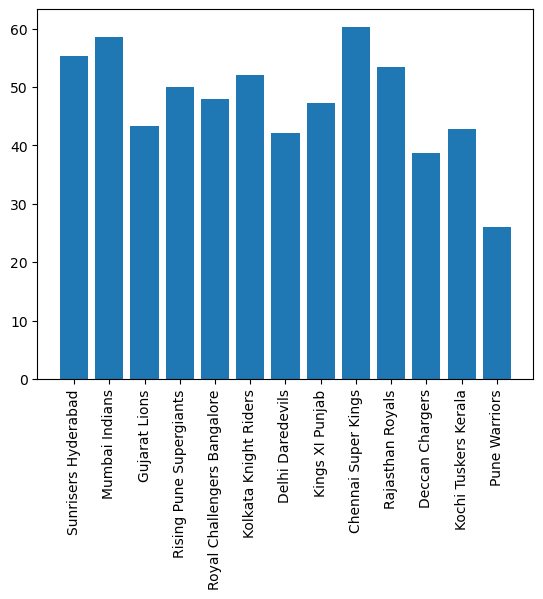

In [26]:
plt.figure(figsize=(14,6))
fig,ax=plt.subplots()
plt.bar(
    win_pd['Team'],
    win_pd['Win Percentage'])
plt.rcParams.update(({"font.size":8,"font.weight":"bold"}))
plt.xticks(rotation=90)
plt.show()

Insight:Chennai Super Kings Holds The Highest Win Rate Over The Years.

# Player Performance Analysis:-

In [27]:
Most_player_match=db['player_of_match'].value_counts()

In [28]:
Most_player_match=Most_player_match.head(10)

<Figure size 800x600 with 0 Axes>

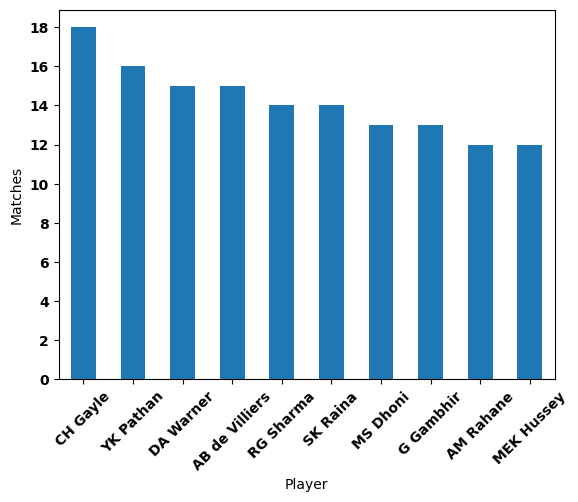

In [53]:
plt.figure(figsize=(8,6))
fig,ax=plt.subplots()
Most_player_match.plot(kind='bar')
plt.xticks(rotation=45)
plt.yticks(range(0,20,2))
plt.xlabel("Player")
plt.ylabel("Matches")
plt.rcParams.update(({"font.size":10,"font.weight":"bold"}))
plt.show()

Insight: CH Gayle Holds The Maximum Player Of The Match Awards, Showing The Highest Individual Performance Throughout The IPL seasons.

# Venue wise Chasing Analysis:-

In [48]:
venues=db['venue'].unique()

In [31]:
venue_win={}
for venue in venues:
    match_at_venues=db[(db['venue']==venue)]
    chasing_win=match_at_venues[((match_at_venues['toss_winner']==match_at_venues['winner'])
                        & (match_at_venues['toss_decision']=='field'))|
                    ((match_at_venues['toss_winner']!=match_at_venues['winner'])
                        & (match_at_venues['toss_decision']=='bat'))]

    win_rate_Fei_venue=(chasing_win.shape[0]/match_at_venues.shape[0])*100

    venue_win[venue]=round(win_rate_Fei_venue,2)

In [32]:
venue_win

{'Rajiv Gandhi International Stadium, Uppal': 61.22,
 'Maharashtra Cricket Association Stadium': 66.67,
 'Saurashtra Cricket Association Stadium': 70.0,
 'Holkar Cricket Stadium': 100.0,
 'M Chinnaswamy Stadium': 56.06,
 'Wankhede Stadium': 49.12,
 'Eden Gardens': 62.3,
 'Feroz Shah Kotla': 55.0,
 'Punjab Cricket Association IS Bindra Stadium, Mohali': 54.55,
 'Green Park': 100.0,
 'Punjab Cricket Association Stadium, Mohali': 57.14,
 'Sawai Mansingh Stadium': 69.7,
 'MA Chidambaram Stadium, Chepauk': 35.42,
 'Dr DY Patil Sports Academy': 58.82,
 'Newlands': 28.57,
 "St George's Park": 57.14,
 'Kingsmead': 46.67,
 'SuperSport Park': 66.67,
 'Buffalo Park': 33.33,
 'New Wanderers Stadium': 62.5,
 'De Beers Diamond Oval': 66.67,
 'OUTsurance Oval': 50.0,
 'Brabourne Stadium': 45.45,
 'Sardar Patel Stadium, Motera': 50.0,
 'Barabati Stadium': 42.86,
 'Vidarbha Cricket Association Stadium, Jamtha': 33.33,
 'Himachal Pradesh Cricket Association Stadium': 44.44,
 'Nehru Stadium': 40.0,
 'Dr.

In [33]:
venue_win=pd.DataFrame(venue_win.items(),
                       columns=['Venue','Chasing Win(%)'])
venue_win.sort_values(by='Chasing Win(%)', ascending=False)
                       

,Venue,Chasing Win(%)
3,Holkar Cricket Stadium,100.00
9,Green Park,100.00
31,JSCA International Stadium Complex,71.43
2,Saurashtra Cricket Association Stadium,70.00
11,Sawai Mansingh Stadium,69.70
17,SuperSport Park,66.67
1,Maharashtra Cricket Association Stadium,66.67
33,Sharjah Cricket Stadium,66.67
30,Shaheed Veer Narayan Singh International Stadium,66.67
20,De Beers Diamond Oval,66.67


<Figure size 1400x600 with 0 Axes>

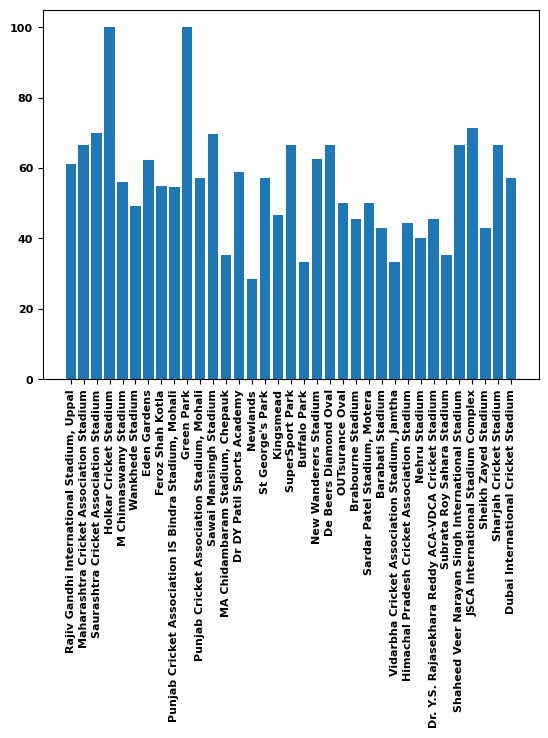

In [34]:
plt.figure(figsize=(14,6))
fig,ax=plt.subplots()
plt.bar(
    venue_win['Venue'],
    venue_win['Chasing Win(%)'])
plt.rcParams.update(({"font.size":8,"font.weight":"bold"}))
plt.xticks(rotation=90)
plt.show()

Insight: This analysis Reveals that some IPL venues Favor Chasing teams more than Others , with Multiple Stadiums Showing Over 60% chasing win Rate. This Suggest that Match conditions at this venues may support Successful run Chases.

# 2 Most Successful Teams Comparison By Win Rate:-

In [35]:
years=db['season'].unique()

In [36]:
csk_year_analysis={}
for year in years:
    csk_match_played=db[((db['team1']=='Chennai Super Kings')|
                        (db['team2']=='Chennai Super Kings'))
                        &
                        (db['season']==year)]
    csk_match_win=db[(db['winner']=='Chennai Super Kings')&
                        (db['season']==year)]
    if csk_match_played.shape[0]!=0:
        csk_percent=(csk_match_win.shape[0]/csk_match_played.shape[0])*100
        csk_year_analysis[year]=round(csk_percent,2)
    

In [37]:
MI_year_analysis={}
for year in years:
    if year==2017:
        continue
    MI_match_played=db[((db['team1']=='Mumbai Indians')|
                        (db['team2']=='Mumbai Indians'))
                        &
                        (db['season']==year)]
    MI_match_win=db[(db['winner']=='Mumbai Indians')&
                        (db['season']==year)]
    if MI_match_played.shape[0]!=0:
        MI_percent=(MI_match_win.shape[0]/MI_match_played.shape[0])*100
        MI_year_analysis[year]=round(MI_percent,2)
    

In [38]:
csk_year_analysis=pd.DataFrame(csk_year_analysis.items(),
                               columns=['Year','Csk_win_Percent'])

In [39]:
MI_year_analysis=pd.DataFrame(MI_year_analysis.items(),
                               columns=['Year','MI_win_Percent'])


In [40]:
MI_year_analysis

,Year,MI_win_Percent
0,2008,50.00
1,2009,38.46
2,2010,68.75
3,2011,62.50
4,2012,58.82
5,2013,68.42
6,2014,46.67
7,2015,62.50
8,2016,50.00


In [41]:
csk_year_analysis

,Year,Csk_win_Percent
0,2008,56.25
1,2009,57.14
2,2010,56.25
3,2011,68.75
4,2012,55.56
5,2013,66.67
6,2014,62.50
7,2015,58.82


MI_year_analysis=dict(sorted(MI_year_analysis.items()))

In [42]:
MI_year_analysis

,Year,MI_win_Percent
0,2008,50.00
1,2009,38.46
2,2010,68.75
3,2011,62.50
4,2012,58.82
5,2013,68.42
6,2014,46.67
7,2015,62.50
8,2016,50.00


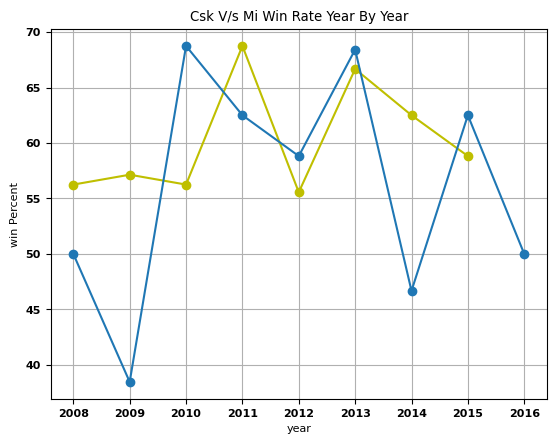

In [43]:
plt.plot(csk_year_analysis['Year'],
         csk_year_analysis['Csk_win_Percent'],
         color='y',
        marker='o')
plt.plot(MI_year_analysis['Year'],
         MI_year_analysis['MI_win_Percent'],
         marker='o')
plt.title('Csk V/s Mi Win Rate Year By Year')
plt.xlabel('year')
plt.ylabel('win Percent')
plt.grid()
plt.show()

INSIGHT: Both Csk And MI Maitained Strong Win Percentages Across IPL Seasons , although MI showed Larger Fluctuations in Performance While CSK remained
Comparatively more Consistent over the Years.